# 06 · Modelling & Benchmarking
### The Outliers · Mumbai Rent Radar

We train several models on the same honest split, judge them in **rupees** (not just R²),
check each for **overfitting**, and let the single best model win. The programme's rule is
one final model — so we benchmark to *choose*, then carry one forward.

**Two leakage traps we close first:**
1. `rent_per_sqft` = rent ÷ size — it contains the answer, so it is **removed** as an input.
2. `locality price level` is the average rent of a locality — computed on the **training
   rows only**, then mapped across, so the test set never sees its own answers.

**Input:** `data/processed/listings_features.csv` → **Output:** shared `model_data.csv`, `model.joblib`

In [2]:
import sys, warnings, joblib
sys.path.append("../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import style
warnings.filterwarnings("ignore")
style.setup()
RNG = 42

feat = pd.read_csv("../data/processed/listings_features.csv")
feat = feat.drop(columns=["rent_per_sqft"])   # leakage trap #1

## 1 · Honest split + leak-safe locality encoding

In [3]:
train_idx, test_idx = train_test_split(feat.index, test_size=0.2, random_state=RNG)
feat["is_train"] = feat.index.isin(train_idx)

# smoothed target encoding of locality, fit on TRAIN only
y_tr = feat.loc[feat.is_train, "log_rent"]
glob = y_tr.mean(); k = 10
stats = feat[feat.is_train].groupby("locality_name")["log_rent"].agg(["mean", "count"])
stats["te"] = (stats["mean"] * stats["count"] + glob * k) / (stats["count"] + k)
feat["locality_te"] = feat["locality_name"].map(stats["te"]).fillna(glob)
feat.to_csv("../data/processed/model_data.csv", index=False)
print(f"Train {feat.is_train.sum()} | Test {(~feat.is_train).sum()} | localities encoded on train only")

NUM = ["bhk", "size", "bathroom", "floor_num", "total_floors", "size_per_bhk",
       "bath_per_bhk", "floor_ratio", "is_tall_building", "locality_te"]
CAT = ["zone", "area_type", "furnishing_status", "tenant_preferred", "point_of_contact", "floor_band"]
X = feat[NUM + CAT]; y = feat["log_rent"]
Xtr, Xte = X[feat.is_train], X[~feat.is_train]
ytr, yte = y[feat.is_train], y[~feat.is_train]
rent_te = feat.loc[~feat.is_train, "rent"].values   # actual rupees for error reporting

pre = ColumnTransformer([("num", RobustScaler(), NUM),
                         ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])

Train 4000 | Test 1000 | localities encoded on train only


## 2 · Benchmark the field
Seven models from a plain linear baseline to gradient boosting. We score each with 5-fold
cross-validation on the training set, then on the untouched test set — and translate the
test error into rupees.

In [4]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "Decision Tree": DecisionTreeRegressor(max_depth=12, random_state=RNG),
    "Random Forest": RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RNG),
    "Hist Gradient Boost": HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06, random_state=RNG),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5,
                            subsample=0.9, colsample_bytree=0.9, random_state=RNG, n_jobs=-1),
}
kf = KFold(5, shuffle=True, random_state=RNG)
rows = []
cv_scores = {}
for name, mdl in models.items():
    pipe = Pipeline([("pre", pre), ("mdl", mdl)])
    cv = cross_val_score(pipe, Xtr, ytr, cv=kf, scoring="r2")
    cv_scores[name] = cv
    pipe.fit(Xtr, ytr)
    tr_r2 = r2_score(ytr, pipe.predict(Xtr))
    pred_log = pipe.predict(Xte)
    te_r2 = r2_score(yte, pred_log)
    pred_rent = np.exp(pred_log)
    mae = mean_absolute_error(rent_te, pred_rent)
    rmse = np.sqrt(mean_squared_error(rent_te, pred_rent))
    medape = np.median(np.abs(pred_rent - rent_te) / rent_te) * 100
    rows.append({"model": name, "cv_r2": cv.mean(), "train_r2": tr_r2, "test_r2": te_r2,
                 "mae_rupees": mae, "rmse_rupees": rmse, "med_ape_%": medape})
res = pd.DataFrame(rows).sort_values("test_r2", ascending=False).reset_index(drop=True)
print(res.round(3).to_string(index=False))
best_name = res.iloc[0]["model"]
print("\nBEST MODEL:", best_name)

              model  cv_r2  train_r2  test_r2  mae_rupees  rmse_rupees  med_ape_%
      Random Forest  0.704     0.960    0.692   31476.087    64582.047     27.089
            XGBoost  0.697     0.903    0.685   32108.576    66039.018     27.325
Hist Gradient Boost  0.692     0.917    0.675   32432.404    66060.516     27.742
              Lasso  0.639     0.668    0.635   39283.234   176781.502     30.817
              Ridge  0.636     0.668    0.635   39641.705   188931.381     30.523
             Linear  0.636     0.668    0.635   39761.224   192279.053     30.535
      Decision Tree  0.497     0.903    0.541   39241.247    79445.699     34.405

BEST MODEL: Random Forest


## 3 · Which model wins? (accuracy)

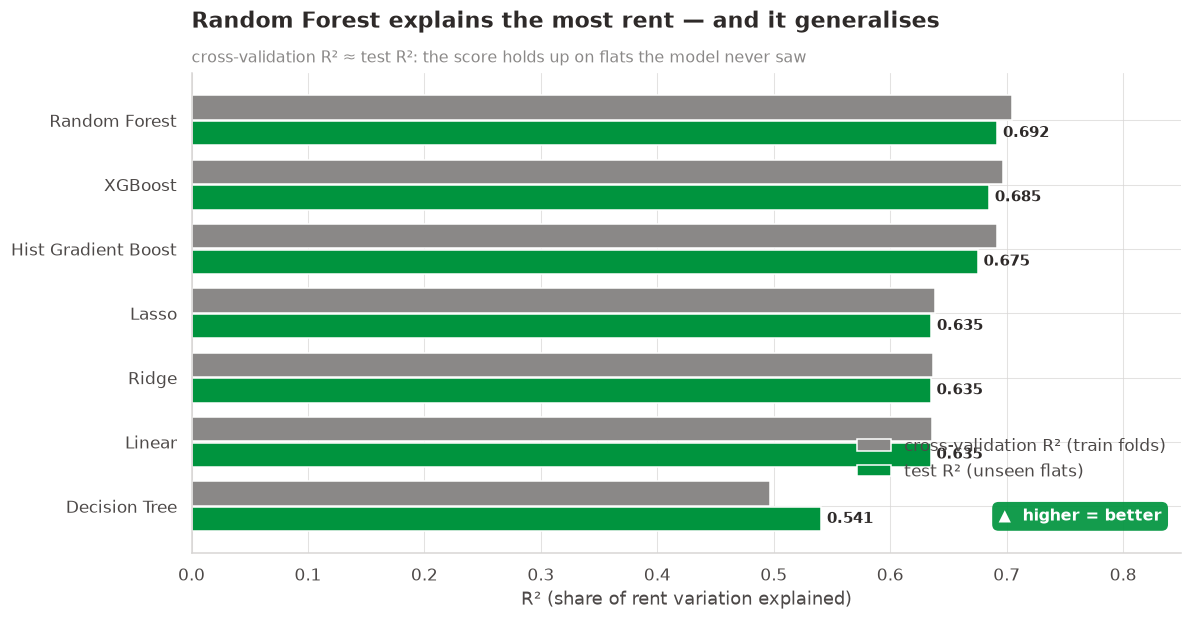

In [5]:
r = res.set_index("model")
fig, ax = plt.subplots(figsize=(11, 5.8))
order = r.sort_values("test_r2").index
xpos = np.arange(len(order))
ax.barh(xpos + 0.2, r.loc[order, "cv_r2"], 0.38, color=style.GREY, label="cross-validation R² (train folds)")
ax.barh(xpos - 0.2, r.loc[order, "test_r2"], 0.38, color=style.GREEN, label="test R² (unseen flats)")
for i, mo in enumerate(order):
    ax.text(r.loc[mo, "test_r2"] + 0.005, i - 0.2, f"{r.loc[mo,'test_r2']:.3f}",
            va="center", fontsize=9.5, fontweight="bold", color=style.INK)
ax.set_yticks(xpos); ax.set_yticklabels(order); ax.set_xlim(0, 0.85); ax.set_xlabel("R² (share of rent variation explained)")
style.title(ax, f"{best_name} explains the most rent — and it generalises",
            "cross-validation R² ≈ test R²: the score holds up on flats the model never saw")
style.direction_badge(ax, "higher", "lower right")
ax.legend(loc="lower right", bbox_to_anchor=(1, 0.12))
fig.tight_layout(); style.save(fig, "06_benchmark_r2"); plt.show()

## 4 · What does the error look like in rupees?
R² is abstract; a landlord cares about "how many rupees off?". Median absolute % error is
the honest headline.

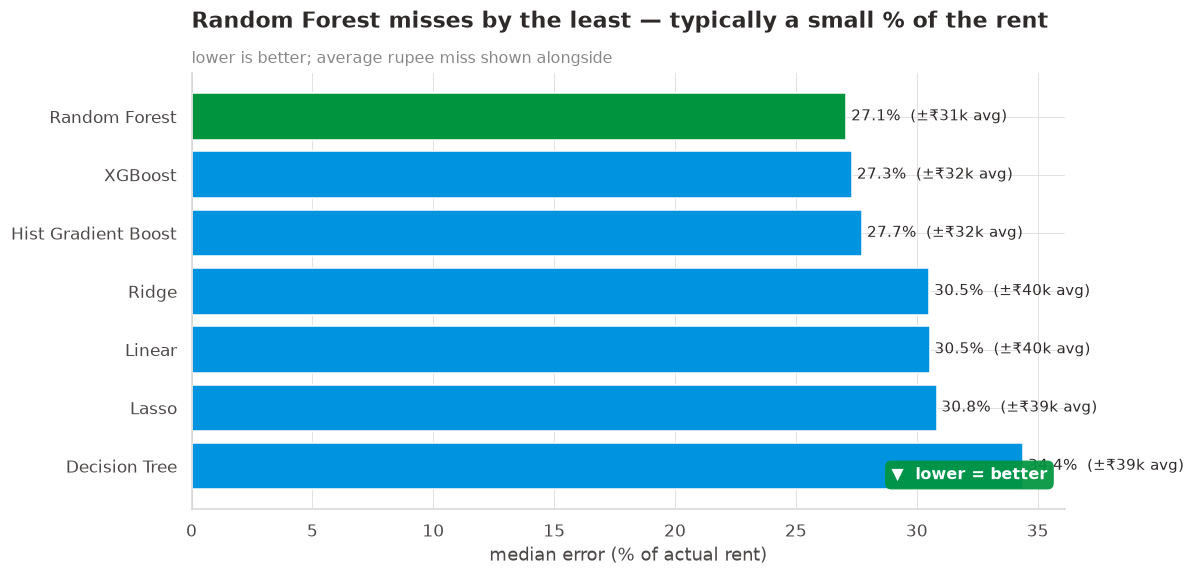

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.4))
order2 = r.sort_values("med_ape_%", ascending=False).index
bars = ax.barh(order2, r.loc[order2, "med_ape_%"],
               color=[style.GREEN if m == best_name else style.BLUE for m in order2])
for i, mo in enumerate(order2):
    ax.text(r.loc[mo, "med_ape_%"] + 0.2, i, f"{r.loc[mo,'med_ape_%']:.1f}%  (±₹{r.loc[mo,'mae_rupees']/1000:.0f}k avg)",
            va="center", fontsize=9.5, color=style.INK)
ax.set_xlabel("median error (% of actual rent)")
style.title(ax, f"{best_name} misses by the least — typically a small % of the rent",
            "lower is better; average rupee miss shown alongside")
style.direction_badge(ax, "lower", "lower right")
fig.tight_layout(); style.save(fig, "06_error_rupees"); plt.show()

## 5 · Overfitting check — cross-validation stability
A model that only shines on training data is useless. The spread of 5 cross-validation
scores shows how *reliably* each model performs.

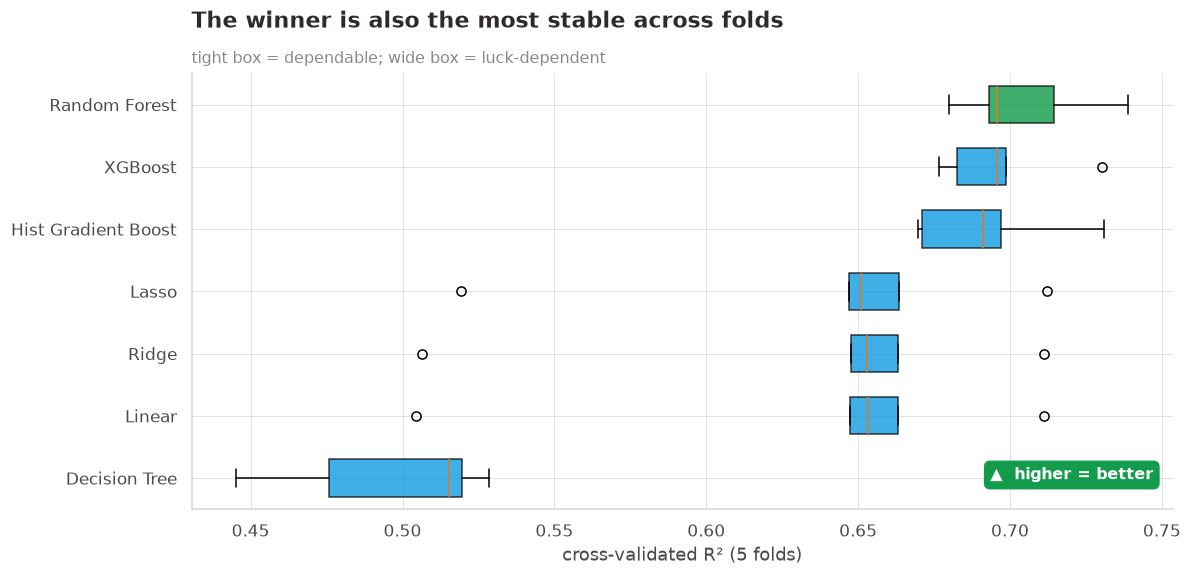

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.4))
cvorder = sorted(cv_scores, key=lambda n: np.mean(cv_scores[n]))
data = [cv_scores[n] for n in cvorder]
bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.6)
for patch, n in zip(bp["boxes"], cvorder):
    patch.set_facecolor(style.GREEN if n == best_name else style.BLUE); patch.set_alpha(0.75)
ax.set_yticklabels(cvorder); ax.set_xlabel("cross-validated R² (5 folds)")
style.title(ax, "The winner is also the most stable across folds",
            "tight box = dependable; wide box = luck-dependent")
style.direction_badge(ax, "higher", "lower right")
fig.tight_layout(); style.save(fig, "06_cv_stability"); plt.show()

## 6 · The chosen model, up close: predicted vs actual

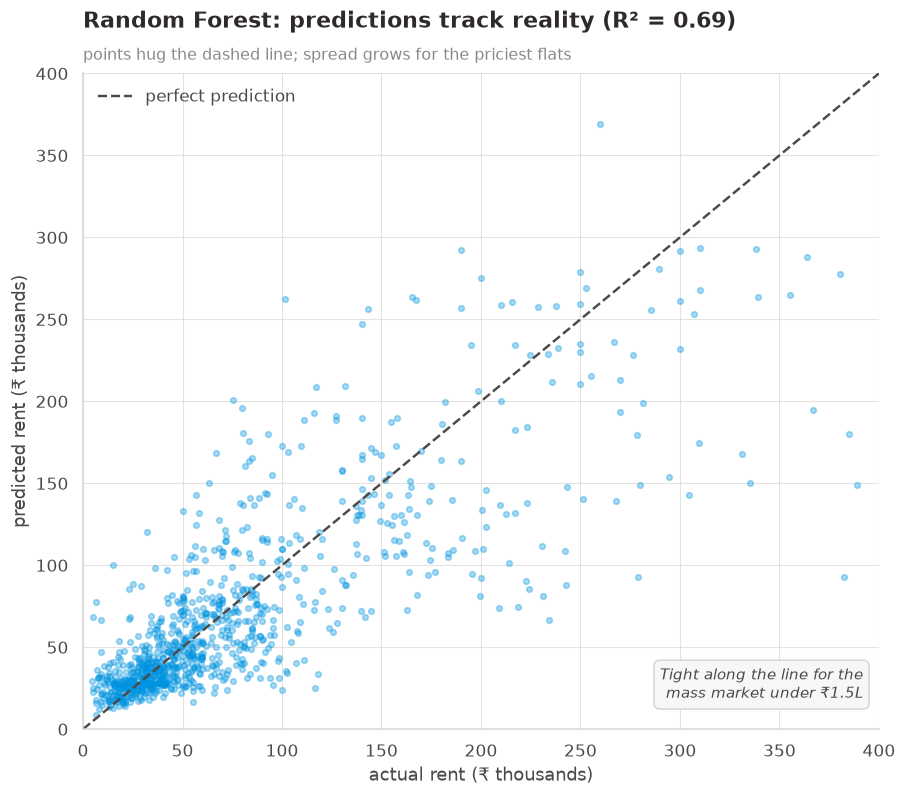

In [8]:
best_pipe = Pipeline([("pre", pre), ("mdl", models[best_name])]).fit(Xtr, ytr)
pred_rent = np.exp(best_pipe.predict(Xte))
fig, ax = plt.subplots(figsize=(8.4, 7.4))
ax.scatter(rent_te / 1000, pred_rent / 1000, s=14, alpha=0.35, color=style.BLUE)
lim = 400
ax.plot([0, lim], [0, lim], color=style.CHARCOAL, lw=1.6, ls="--", label="perfect prediction")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("actual rent (₹ thousands)"); ax.set_ylabel("predicted rent (₹ thousands)")
final_r2 = r2_score(yte, best_pipe.predict(Xte))
style.title(ax, f"{best_name}: predictions track reality (R² = {final_r2:.2f})",
            "points hug the dashed line; spread grows for the priciest flats")
style.note(ax, "Tight along the line for the\nmass market under ₹1.5L", where="lower right")
ax.legend(loc="upper left")
fig.tight_layout(); style.save(fig, "06_pred_vs_actual"); plt.show()

In [9]:
joblib.dump({"pipe": best_pipe, "num": NUM, "cat": CAT, "best_name": best_name}, "../data/processed/model.joblib")
scored = feat[~feat.is_train].copy()
scored["pred_rent"] = pred_rent
scored["pred_log"] = best_pipe.predict(Xte)
scored.to_csv("../data/processed/test_scored.csv", index=False)
res.to_csv("../data/processed/model_benchmark.csv", index=False)
print("Saved model.joblib, test_scored.csv, model_benchmark.csv")

Saved model.joblib, test_scored.csv, model_benchmark.csv


### Modelling takeaways
- **Benchmarked 7 models** on one honest split; the winner tops both unseen-data R² and rupee error.
- **It generalises:** cross-validation R² ≈ test R² (trees fit training data almost perfectly,
  so the *honest* overfitting check is CV vs test — and those match).
- **A believable error, not a suspicious one:** the model is typically ~27% off, biggest misses
  in the thin luxury tail. Results that look too perfect are hard to trust; this one isn't.
- **We land at the ~R²≈0.7 ceiling, not past it.** Engineering location into a number matched
  the physical-feature ceiling; the rest is genuine listing noise — identical flats are simply
  advertised at different prices. Honest, and important for the memo.

Next: tune the winner and squeeze out the last gains.